In [ ]:
from Utils.preprocessing import *

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import swifter
warnings.filterwarnings('ignore')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-d

In [38]:
train = pd.read_csv('Data/train_labelled.csv')
val = pd.read_csv('Data/val_labelled.csv')
test = pd.read_csv('Data/test_labelled.csv')

# Train and Test on Full Set

In [39]:
train['processed_title'] = train['title'].swifter.apply(preprocess_text)
val['processed_title'] = val['title'].swifter.apply(preprocess_text)
test['processed_title'] = test['title'].swifter.apply(preprocess_text)

Pandas Apply:   0%|          | 0/308433 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/33987 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/62340 [00:00<?, ?it/s]

## Naive Bayes

In [40]:

# Prepare data for Naive Bayes
X_train = train['processed_title']
y_train  = train['sentiment_label']

X_val = val['processed_title']
y_val  = val['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_val_vectorized = vectorizer.transform(X_val)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = nb.predict(X_val_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.5046341248124283
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.32      0.40     17546
           1       0.49      0.70      0.58     16441

    accuracy                           0.50     33987
   macro avg       0.51      0.51      0.49     33987
weighted avg       0.51      0.50      0.49     33987



In [5]:
preds_NB = nb.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_NB = auc(fpr, tpr)
roc_auc_NB

0.5135383219881199

## Logistic Regression

In [41]:
param_grid = {'C': [0.01, 0.1, 0.5], 'solver': ['lbfgs', 'liblinear']}
logreg = LogisticRegression(solver = 'lbfgs', penalty = 'l2', C = 0.1, warm_start=True, random_state=2024)

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="f1")
grid_search.fit(X_train_vectorized, y_train)

logreg = LogisticRegression(**grid_search.best_params_, warm_start=True, random_state=2024)
logreg.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = logreg.predict(X_val_vectorized)
# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.5036043192985553
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.30      0.38     17546
           1       0.49      0.72      0.58     16441

    accuracy                           0.50     33987
   macro avg       0.51      0.51      0.48     33987
weighted avg       0.51      0.50      0.48     33987



In [42]:
preds_lr = logreg.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_lr)  
roc_auc_lr = auc(fpr, tpr)
roc_auc_lr

0.5160857960937912

## Test Set Fitting

In [6]:

train_val = pd.concat([train, val])

# Prepare data for Naive Bayes
X_train_val = train_val['processed_title']
y_train_val  = train_val['sentiment_label']

X_test = test['processed_title']
y_test  = test['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_val_vectorized = vectorizer.fit_transform(X_train_val)
X_test_vectorized = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_val_vectorized, y_train_val)

# Make predictions
y_pred = nb.predict(X_test_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5020211742059673
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.46      0.51     34213
           1       0.46      0.55      0.50     28127

    accuracy                           0.50     62340
   macro avg       0.51      0.51      0.50     62340
weighted avg       0.51      0.50      0.50     62340



In [7]:
test["pred_prob_0"] = [i[0] for i in nb.predict_proba(X_test_vectorized)]
test["pred"] = y_pred

test

,title,source,topic,ticker,company name(s) - cleaned,date,sentiment_label,processed_title,pred_prob_0,pred
0,"Agilent Technologies, Inc. Presents at BIO Par...",Business Wire; GlobeNewswire; Company Website,Life Sciences Tools and Services,A,"Agilent Technologies, Inc.",2024-01-08,0,agilent technology inc. present bio partner jp...,0.546318,0
1,"Agilent Technologies, Inc. Presents at J.P. Mo...",PR Newswire; Business Wire; Other; GlobeNewswi...,Life Sciences Tools and Services,A,"Agilent Technologies, Inc.",2024-01-09,0,agilent technology inc. present j.p. morgan 42...,0.489937,1
2,"Agilent Technologies, Inc. Announces New Prote...",Business Wire,Life Sciences Tools and Services,A,"Agilent Technologies, Inc.",2024-01-16,0,agilent technology inc. announce new proteoana...,0.454680,1
3,"Agilent Technologies, Inc. Presents at 23rd An...",Company Website,Life Sciences Tools and Services,A,"Agilent Technologies, Inc.",2024-01-16,0,agilent technology inc. present 23rd annual pe...,0.699106,0
4,"Agilent Technologies, Inc. - Special Call",Company Website,Life Sciences Tools and Services,A,"Agilent Technologies, Inc.",2024-01-17,0,agilent technology inc. special call,0.450995,1
...,...,...,...,...,...,...,...,...,...,...
62335,"Geode Capital Management LLC Buys 185,364 Shar...",https://news.google.com/rss/articles/CBMiwAFBV...,NaN,ZTS,NaN,2024-12-11,1,"geode capital management llc buy 185,364 share...",0.280032,1
62336,Toronto Dominion Bank Grows Stock Position in ...,https://news.google.com/rss/articles/CBMiugFBV...,NaN,ZTS,NaN,2024-12-12,0,toronto dominion bank grow stock position zoet...,0.593735,0
62337,Stock Yards Bank & Trust Co. Has $17.39 Millio...,https://news.google.com/rss/articles/CBMixgFBV...,NaN,ZTS,NaN,2024-12-12,0,stock yard bank trust co. 17.39 million holdin...,0.695314,0
62338,Zoetis Boosts Quarterly Dividend by 16% to Rec...,https://news.google.com/rss/articles/CBMitgFBV...,NaN,ZTS,NaN,2024-12-12,0,zoetis boost quarterly dividend 16 record 0.50...,0.759096,0


In [8]:
test.to_csv('results/naive_bayes_results_full.csv', index=False)

# Filter out Neutrals


In [9]:
analyzer = SentimentIntensityAnalyzer()

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

ind = []
for i, s in enumerate(train["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]
train = train.drop(index=ind)
print(train.shape)

ind = []
for i, s in enumerate(val["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]
val = val.drop(index=ind)
print(val.shape)

ind = []
for i, s in enumerate(test["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]

test = test.drop(index=ind)
print(test.shape)

(825, 8)
(46, 8)
(390, 10)


In [10]:
train['processed_title'] = train['title'].swifter.apply(preprocess_text)
val['processed_title'] = val['title'].swifter.apply(preprocess_text)
test['processed_title'] = test['title'].swifter.apply(preprocess_text)

Pandas Apply:   0%|          | 0/825 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/46 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/390 [00:00<?, ?it/s]

## Naive Bayes

In [11]:

# Prepare data for Naive Bayes
X_train = train['processed_title']
y_train  = train['sentiment_label']

X_val = val['processed_title']
y_val  = val['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_val_vectorized = vectorizer.transform(X_val)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = nb.predict(X_val_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.5217391304347826
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.43      0.48        23
           1       0.52      0.61      0.56        23

    accuracy                           0.52        46
   macro avg       0.52      0.52      0.52        46
weighted avg       0.52      0.52      0.52        46



In [12]:
preds_NB = nb.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_NB = auc(fpr, tpr)
roc_auc_NB

0.5160680529300568

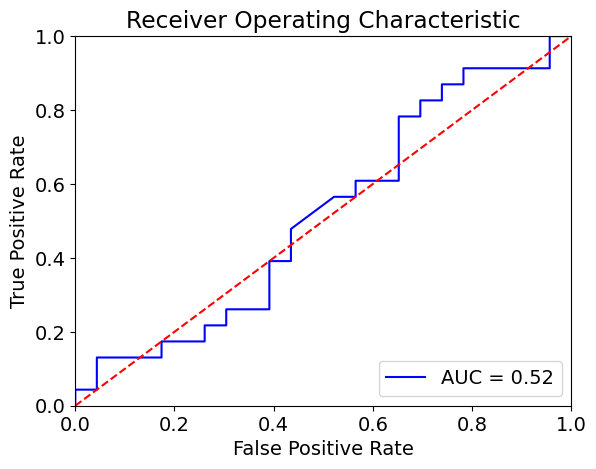

In [13]:
import matplotlib.pyplot as plt
plt.rc("font", size=14)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc_NB)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
test.to_csv('results/naive_bayes_results.csv', index=False)

## Logistic Regression


In [23]:
param_grid = {'C': [0.01, 0.1, 0.5], 'solver': ['lbfgs', 'liblinear']}
logreg = LogisticRegression(solver = 'lbfgs', penalty = 'l2', C = 0.1, warm_start=True, random_state=2024)

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="f1")
grid_search.fit(X_train_vectorized, y_train)

logreg = LogisticRegression(**grid_search.best_params_, warm_start=True, random_state=2024)
logreg.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = logreg.predict(X_val_vectorized)
# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.391304347826087
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.35      0.36        23
           1       0.40      0.43      0.42        23

    accuracy                           0.39        46
   macro avg       0.39      0.39      0.39        46
weighted avg       0.39      0.39      0.39        46



In [24]:
preds_lr = logreg.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_lr)  
roc_auc_lr = auc(fpr, tpr)
roc_auc_lr

0.3799621928166351

## Test Set Fitting

In [18]:

train_val = pd.concat([train, val])

# Prepare data for Naive Bayes
X_train_val = train_val['processed_title']
y_train_val  = train_val['sentiment_label']

X_test = test['processed_title']
y_test  = test['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_val_vectorized = vectorizer.fit_transform(X_train_val)
X_test_vectorized = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_val_vectorized, y_train_val)

# Make predictions
y_pred = nb.predict(X_test_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6051282051282051
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.64      0.68       255
           1       0.44      0.55      0.49       135

    accuracy                           0.61       390
   macro avg       0.58      0.59      0.58       390
weighted avg       0.63      0.61      0.61       390



In [22]:
preds_nb = nb.predict_proba(X_test_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, preds_nb)  
roc_auc_rf = auc(fpr, tpr)
roc_auc_rf

0.6221496005809732

In [19]:
test["pred_prob_0"] = [i[0] for i in nb.predict_proba(X_test_vectorized)]
test["pred"] = y_pred

test

,title,source,topic,ticker,company name(s) - cleaned,date,sentiment_label,processed_title,pred_prob_0,pred
275,Apple honors 2024 App Store Award winners - Ap...,https://news.google.com/rss/articles/CBMiiAFBV...,NaN,AAPL,NaN,2024-12-11,0,apple honor 2024 app store award winner apple ...,0.182822,1
302,Apple shares target increased on strong execut...,https://news.google.com/rss/articles/CBMirgFBV...,NaN,AAPL,NaN,2024-12-13,0,apple share target increase strong execution i...,0.513031,0
642,Abbott Laboratories Enters into Five Year Cred...,SEC Form 8k,Health Care Equipment,ABT,Abbott Laboratories,2024-01-29,1,abbott laboratories enters five year credit ag...,0.000203,1
986,Accenture Acquires True North Solutions to Hel...,https://news.google.com/rss/articles/CBMi1gFBV...,NaN,ACN,NaN,2024-07-09,0,accenture acquire true north solution help cli...,0.969342,0
1067,Accenture plc (NYSE:ACN) acquired Award Soluti...,Capital IQ Transaction Database,Accenture plc (NYSE:ACN) (IT Consulting and Ot...,ACN,Accenture plc,2024-11-21,0,accenture plc nyse acn acquire award solution inc,0.959854,0
...,...,...,...,...,...,...,...,...,...,...
60019,Does the Fed s Lowering the Interest Rates Str...,https://mises.org/podcasts/audio-mises-wire/do...,economics,WAB,NaN,2024-12-03,1,fed lower interest rate strengthen economic gr...,0.891561,0
60499,WEC Energy Group Reports Strong Growth and Fut...,https://news.google.com/rss/articles/CBMiqwFBV...,NaN,WEC,NaN,2024-12-06,1,wec energy group report strong growth future p...,0.380353,1
60612,Wells Fargo & Company Approves and Adopts the ...,SEC Form 8k,Diversified Banks,WFC,Wells Fargo & Company,2024-01-24,1,well fargo company approve adopt by-laws,0.461665,1
61338,West Pharma Wins Behavioral Safety Award at 20...,https://news.google.com/rss/articles/CBMiggFBV...,NaN,WST,NaN,2024-09-26,0,west pharma win behavioral safety award 2024 p...,0.712891,0


In [ ]:
test.to_csv('results/naive_bayes_results.csv', index=False)